# Batterielebensdauer-Experiment

Ein Entwickler untersucht Möglichkeiten zur Verbesserung der Lebensdauer einer Batterie.

Dabei werden zwei Faktoren betrachtet:

- Materialtyp
- Temperatur

## Faktor A: Materialtyp

Qualitativer Faktor mit drei Stufen:

- Typ 1
- Typ 2
- Typ 3

## Faktor B: Temperatur

Quantitativer Faktor mit drei Stufen:

- 15 °F
- 70 °F
- 125 °F

## Antwortvariable

Batterielebensdauer [h]

## Datengrundlage

![title](../img/table5-1.png)

## Fragestellungen

- Welchen Einfluss haben Materialtyp und Temperatur auf die Lebensdauer?
- Existiert eine Wechselwirkung zwischen beiden Faktoren?
- Gibt es einen Materialtyp, der unabhängig von der Temperatur eine hohe Lebensdauer aufweist?

## Ziele der Analyse

- Erstellung eines faktoriellen Versuchsplans
- Zwei-Faktor-ANOVA
- Untersuchung von Wechselwirkungen
- Interaction Plot
- Regressionsmodell

# Dateneingabe

In [26]:
import pandas as pd

df = pd.DataFrame({

    "Material": (
        ["Type 1"]*12 +
        ["Type 2"]*12 +
        ["Type 3"]*12
    ),

    "Temperature": (
        [15]*4 + [70]*4 + [125]*4
    ) * 3,

    "Life": [

        130,74,155,180,
        34,80,40,75,
        20,82,70,58,

        150,159,188,126,
        136,106,122,115,
        25,58,70,45,

        138,168,110,160,
        174,150,120,139,
        96,82,104,60
    ]
})

df.head()

,Material,Temperature,Life
0,Type 1,15,130
1,Type 1,15,74
2,Type 1,15,155
3,Type 1,15,180
4,Type 1,70,34


# Faktorieller Versuchsplan

Es handelt sich um einen

$3 \times 3$

faktoriellen Versuchsplan mit

- 3 Materialtypen
- 3 Temperaturstufen
- 4 Wiederholungen

insgesamt also

$3\times3\times4
=
36
$

Versuche.

In [18]:
from pyDOE3 import fullfact

design = fullfact([
    3,  # Material
    3   # Temperatur
])

design

array([[0., 0.],
       [1., 0.],
       [2., 0.],
       [0., 1.],
       [1., 1.],
       [2., 1.],
       [0., 2.],
       [1., 2.],
       [2., 2.]])

In [28]:
import pandas as pd

df_design = pd.DataFrame(
    design,
    columns=["Material","Temperature"]
)

df_design["Material"] = (
    df_design["Material"]+1
).astype(int)

df_design["Temperature"] = (
    df_design["Temperature"]
    .map({
        0:15,
        1:70,
        2:125
    })
)

df_design

,Material,Temperature
0,1,15
1,2,15
2,3,15
3,1,70
4,2,70
5,3,70
6,1,125
7,2,125
8,3,125


In [30]:
df_design = pd.concat(
    [df_design]*4,
    ignore_index=True
)

df_design

,Material,Temperature
0,1,15
1,2,15
2,3,15
3,1,70
4,2,70
...,...,...
139,2,70
140,3,70
141,1,125
142,2,125


In [31]:
df_design = df_design.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df_design

,Material,Temperature
0,1,15
1,2,15
2,2,15
3,2,125
4,3,15
...,...,...
139,3,125
140,2,125
141,3,70
142,3,15


# Zellmittelwerte

In [32]:
means = df.pivot_table(
    values="Life",
    index="Material",
    columns="Temperature",
    aggfunc="mean"
)

means.round(1)

Temperature,15,70,125
Material,,,
Type 1,134.8,57.2,57.5
Type 2,155.8,119.8,49.5
Type 3,144.0,145.8,85.5


# Heatmap

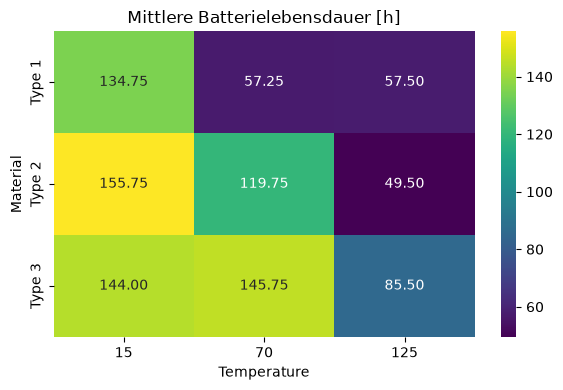

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    means,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title(
    "Mittlere Batterielebensdauer [h]"
)

plt.tight_layout()

plt.show()

# Zweifaktorielle Varianzanalyse

Das Modell lautet

$
y_{ijk}
=
\mu
+
\tau_i
+
\beta_j
+
(\tau\beta)_{ij}
+
\epsilon_{ijk}
$

mit

- Materialtyp
- Temperatur
- Wechselwirkung Material × Temperatur

In [37]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model = ols(
    "Life ~ C(Material)*C(Temperature)",
    data=df
).fit()

anova_table = anova_lm(
    model,
    typ=2
)

anova_table["MS"] = (
    anova_table["sum_sq"]
    /
    anova_table["df"]
)

anova_table.round(3)

,sum_sq,df,F,PR(>F),MS
C(Material),10683.722,2.0,7.911,0.002,5341.861
C(Temperature),39118.722,2.0,28.968,0.000,19559.361
C(Material):C(Temperature),9613.778,4.0,3.560,0.019,2403.444
Residual,18230.750,27.0,NaN,NaN,675.213


# Prozentuale Varianzanteile

In [38]:
anova_table["Percent"] = (
    100
    *
    anova_table["sum_sq"]
    /
    anova_table["sum_sq"].sum()
)

anova_table.round(2)

,sum_sq,df,F,PR(>F),MS,Percent
C(Material),10683.72,2.0,7.91,0.00,5341.86,13.76
C(Temperature),39118.72,2.0,28.97,0.00,19559.36,50.38
C(Material):C(Temperature),9613.78,4.0,3.56,0.02,2403.44,12.38
Residual,18230.75,27.0,NaN,NaN,675.21,23.48


# Haupteffekte
## Material

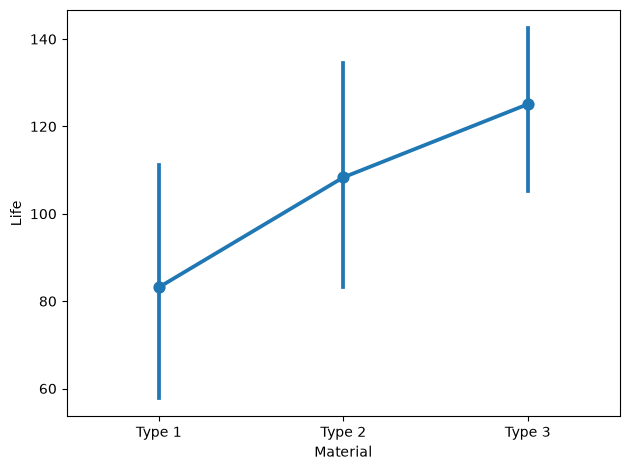

In [9]:

material_means = (
    df.groupby("Material")
      ["Life"]
      .mean()
)

material_means

sns.pointplot(
    data=df,
    x="Material",
    y="Life",
    errorbar=("ci",95)
)

plt.tight_layout()
plt.show()

## Temperatur

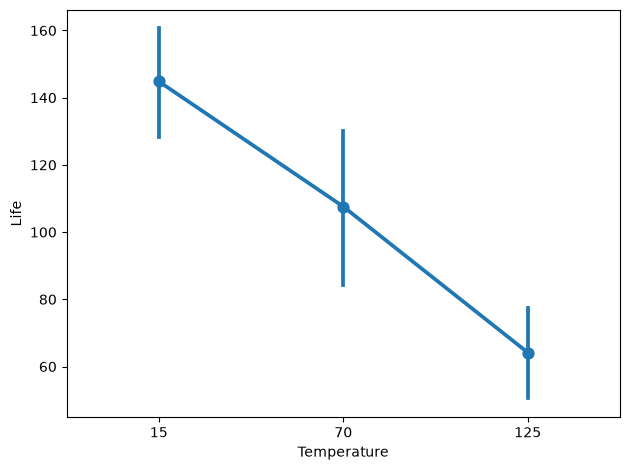

In [10]:
temp_means = (
    df.groupby("Temperature")
      ["Life"]
      .mean()
)

temp_means

sns.pointplot(
    data=df,
    x="Temperature",
    y="Life",
    errorbar=("ci",95)
)

plt.tight_layout()
plt.show()

## Interaction Plot

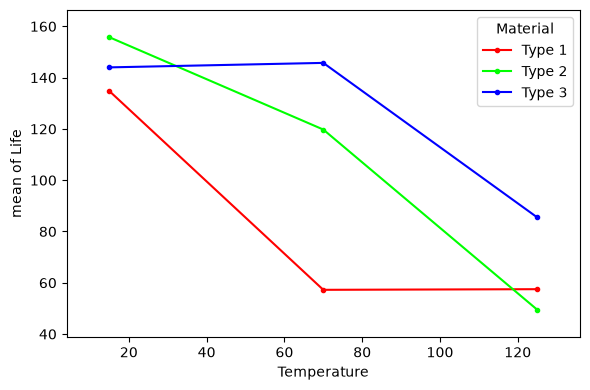

In [11]:
from statsmodels.graphics.factorplots import interaction_plot

fig, ax = plt.subplots(figsize=(6,4))

interaction_plot(
    df["Temperature"],
    df["Material"],
    df["Life"],
    ax=ax
)

plt.tight_layout()

plt.show()

# Interpretation

Parallel verlaufende Linien würden auf das Fehlen einer Wechselwirkung hindeuten.

Nicht parallele Linien zeigen, dass der Einfluss der Temperatur vom Materialtyp abhängt.

Da der Interaktionsterm in der ANOVA signifikant ist, sollten die Haupteffekte nicht isoliert interpretiert werden.

# Multiple Comparisons
## Materialtypen

In [12]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_material = pairwise_tukeyhsd(
    df["Life"],
    df["Material"]
)

print(tukey_material)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
Type 1 Type 2  25.1667 0.3687  -19.959 70.2924  False
Type 1 Type 3  41.9167 0.0729   -3.209 87.0424  False
Type 2 Type 3    16.75 0.6374 -28.3757 61.8757  False
-----------------------------------------------------


# Residuenanalyse
## QQ-Plot

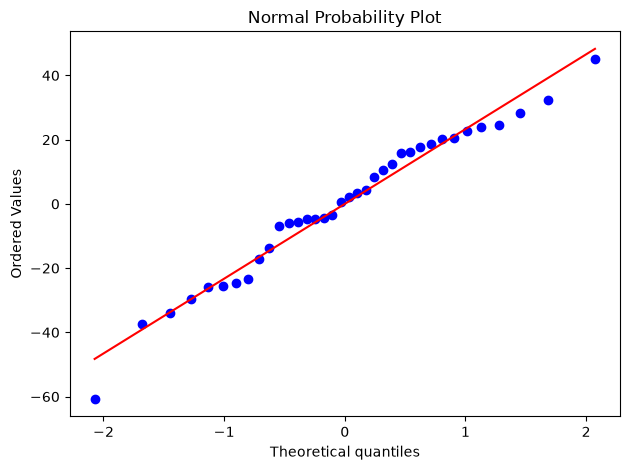

In [13]:
from scipy import stats

stats.probplot(
    model.resid,
    dist="norm",
    plot=plt
)

plt.title(
    "Normal Probability Plot"
)

plt.tight_layout()

plt.show()

## Residuen gegen Fits

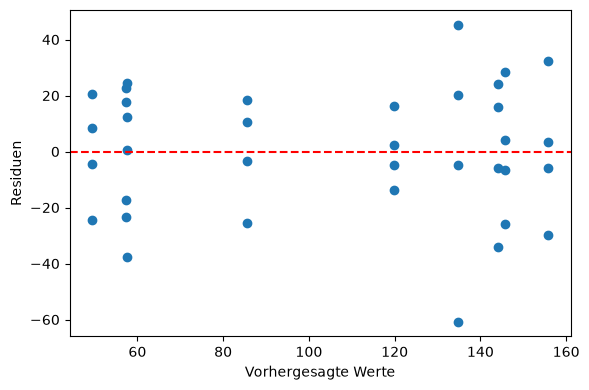

In [14]:
plt.figure(figsize=(6,4))

plt.scatter(
    model.fittedvalues,
    model.resid
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Residuen")

plt.tight_layout()

plt.show()

# Quantitativer Faktor: Temperatur

In [15]:
import statsmodels.formula.api as smf

reg_model = smf.ols(
    "Life ~ C(Material)*(Temperature + I(Temperature**2))",
    data=df
).fit()

print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Life   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     11.00
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           9.43e-07
Time:                        11:35:29   Log-Likelihood:                -163.17
No. Observations:                  36   AIC:                             344.3
Df Residuals:                      27   BIC:                             358.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

# Wirkungskurven

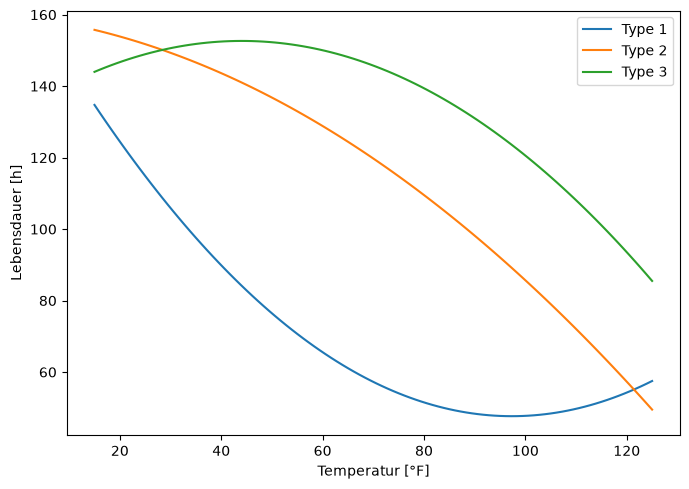

In [16]:
import numpy as np

temps = np.linspace(
    15,
    125,
    100
)

fig, ax = plt.subplots(
    figsize=(7,5)
)

for m in df["Material"].unique():

    pred_df = pd.DataFrame({
        "Material": m,
        "Temperature": temps
    })

    pred = reg_model.predict(
        pred_df
    )

    ax.plot(
        temps,
        pred,
        label=m
    )

ax.set_xlabel(
    "Temperatur [°F]"
)

ax.set_ylabel(
    "Lebensdauer [h]"
)

ax.legend()

plt.tight_layout()
plt.show()

